## Desafio SENL Cobb Douglas

En este desafio, modelaremos dos diferentes situaciones:

1. Simulacion Montecarlo aplicada a acciones SP500

2. Simulacion ruleta de casino

### Simulacion Montecarlo aplicada a acciones SP500


a. Accion elegida: **PEP, PepsiCo**

b. Analistas estiman: <br>
Low: $160 <br>
Average: $173 <br>
High: $191 


c. Instalar yahoo finance:

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt


In [2]:
ticker = yf.Ticker("PEP")
data = ticker.history(period="1y")

d. Para calcular la rentabilidad, usamos pct_change(). 

In [3]:

data['Rentabilidad'] = data[('Close')].pct_change()
data = data.dropna()

Agrupamos por dia y mes:

In [4]:
# Extraer el mes del índice
data['Month'] = data.index.month

# Agrupar las rentabilidades en un diccionario
# Esto crea una lista de retornos para cada mes (1 al 12)
returns_by_month = data.groupby('Month')['Rentabilidad'].apply(list).to_dict()
returns_by_month[4]

[0.016063290169790356,
 -0.026643986883532644,
 -0.019252440802722037,
 0.01963037340462992,
 -0.007771015901673506,
 0.012206459955293347,
 -0.00836477521968948,
 -0.04885421568174664,
 -0.014263538797428366,
 0.002848939119989069,
 0.004111894012630568,
 0.009455718112902245,
 -0.004121317646457734,
 0.015260269663710746,
 -0.0017833181905161366,
 -0.022458936448840672,
 0.010377888311564831,
 0.0173772764106912,
 -0.002730382370765616]

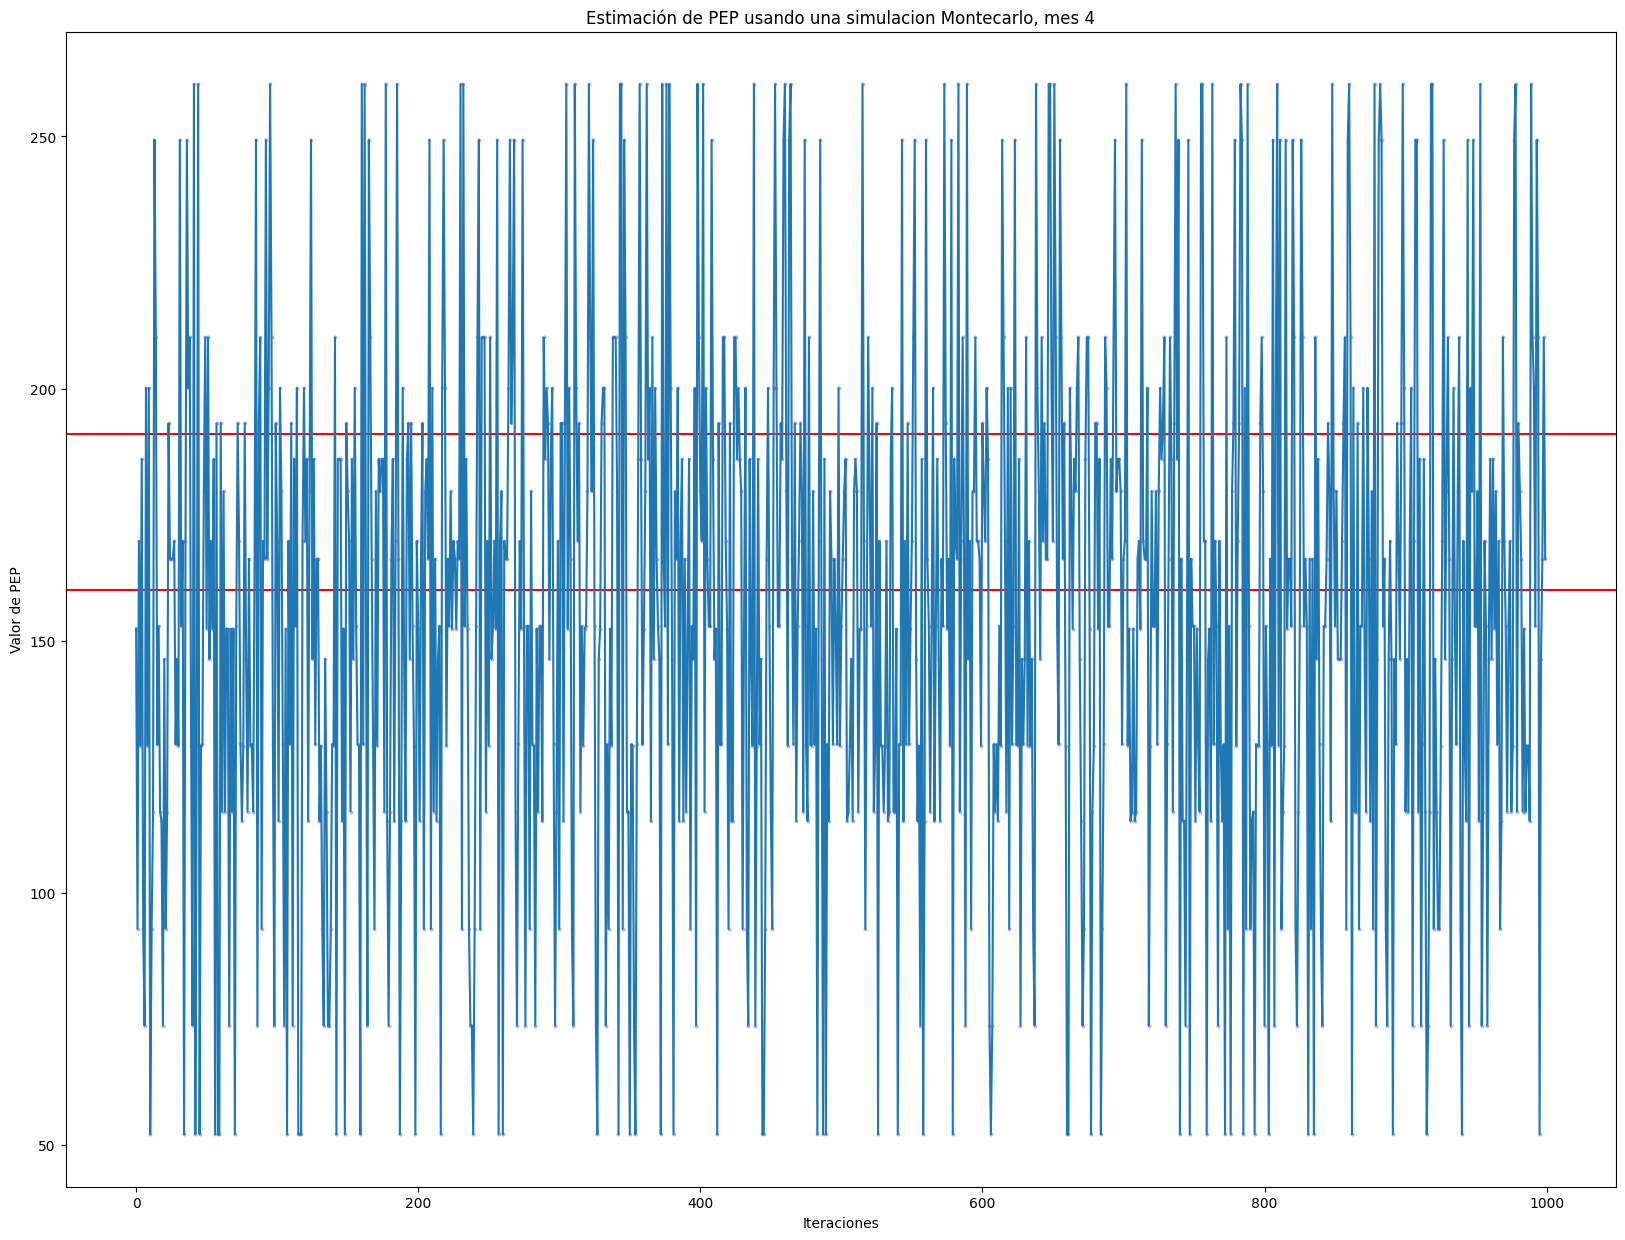

Porcentaje de exito: 22.400000000000002
La simulacion tomo: 2.3368003368377686 s


In [5]:
import time

def monte_carlo(runs, month):
    sim_values = []
    start_price = data['Close'].iloc[-1]
    chosenMonth = returns_by_month[month]

    lowTarget = 160
    highTarget = 191

    plt.figure(figsize=(20, 15))

    # Low target
    plt.axhline(y=160, color='r', linestyle='-')
    # High target
    plt.axhline(y=191, color='r', linestyle='-')
    nhits = 0

    # Para todas las ejecuciones:
    for i in range(runs):
        # Elegir dia aleatorio
        idxDia = random.randint(0, len(chosenMonth) - 1)
        r_random = chosenMonth[idxDia]
        # Calculamos cuantos dias quedan dentro del mes elegido
        dias_restantes = 30 - (idxDia + 1)
        # Calcular ganancia final: precio inicial * (porcentaje de ganancia, elevado a cuantas veces se repite la ganancia en el mes) 
        final_price = start_price * ((1 + r_random) ** dias_restantes)
        
        # Guardamos para el plot
        sim_values.append(final_price)
        
        # Vemos si el valor cae en el rango
        if lowTarget <= final_price <= highTarget:
            nhits += 1
            
        # Graficamos el punto
        plt.plot(i, final_price, 'bo', markersize=2, alpha=0.2)
    
    success_rate = (nhits / runs) * 100
        


    # Graficar los valores
    plt.plot(sim_values)
    plt.xlabel('Iteraciones')
    plt.ylabel('Valor de PEP')
    plt.title(f'Estimación de PEP usando una simulacion Montecarlo, mes {month}')
    plt.show()

    print(f'Porcentaje de exito: {success_rate}')

    return success_rate

# Ejemplo de uso
monteCarloTime1 = time.time()
pep1 = monte_carlo(runs=1000, month=4)
monteCarloTime2 = time.time() - monteCarloTime1
print('La simulacion tomo:', monteCarloTime2,'s')

Como un bonus, podemos correr la misma simulacion pero con 2000 iteraciones, en junio:

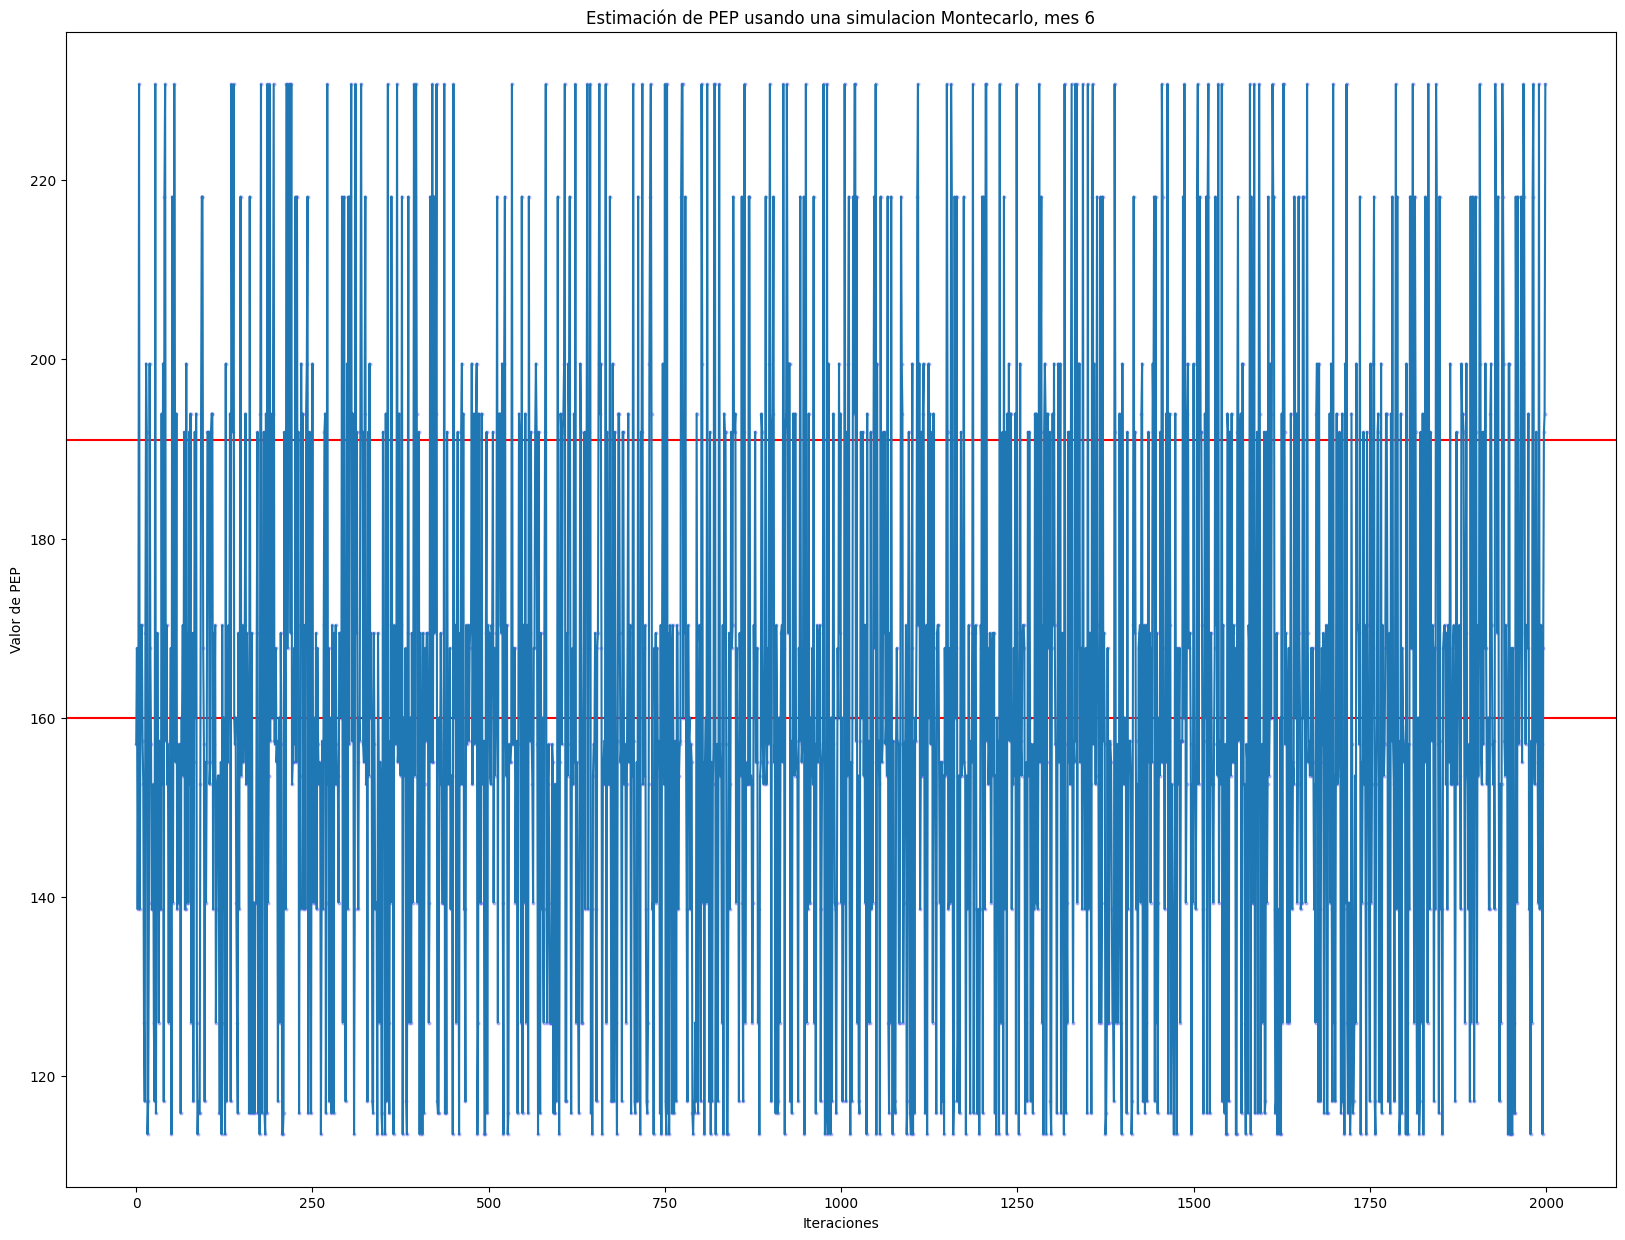

Porcentaje de exito: 20.1
La simulacion tomo: 4.094727039337158 s


In [6]:
monteCarlo2Time1 = time.time()
pep2 = monte_carlo(2000, 6)
monteCarlo2Time2 = time.time() - monteCarlo2Time1
print('La simulacion tomo:', monteCarlo2Time2, 's')

Ahora, otra simulacion, con 3000 iteraciones y en diciembre:

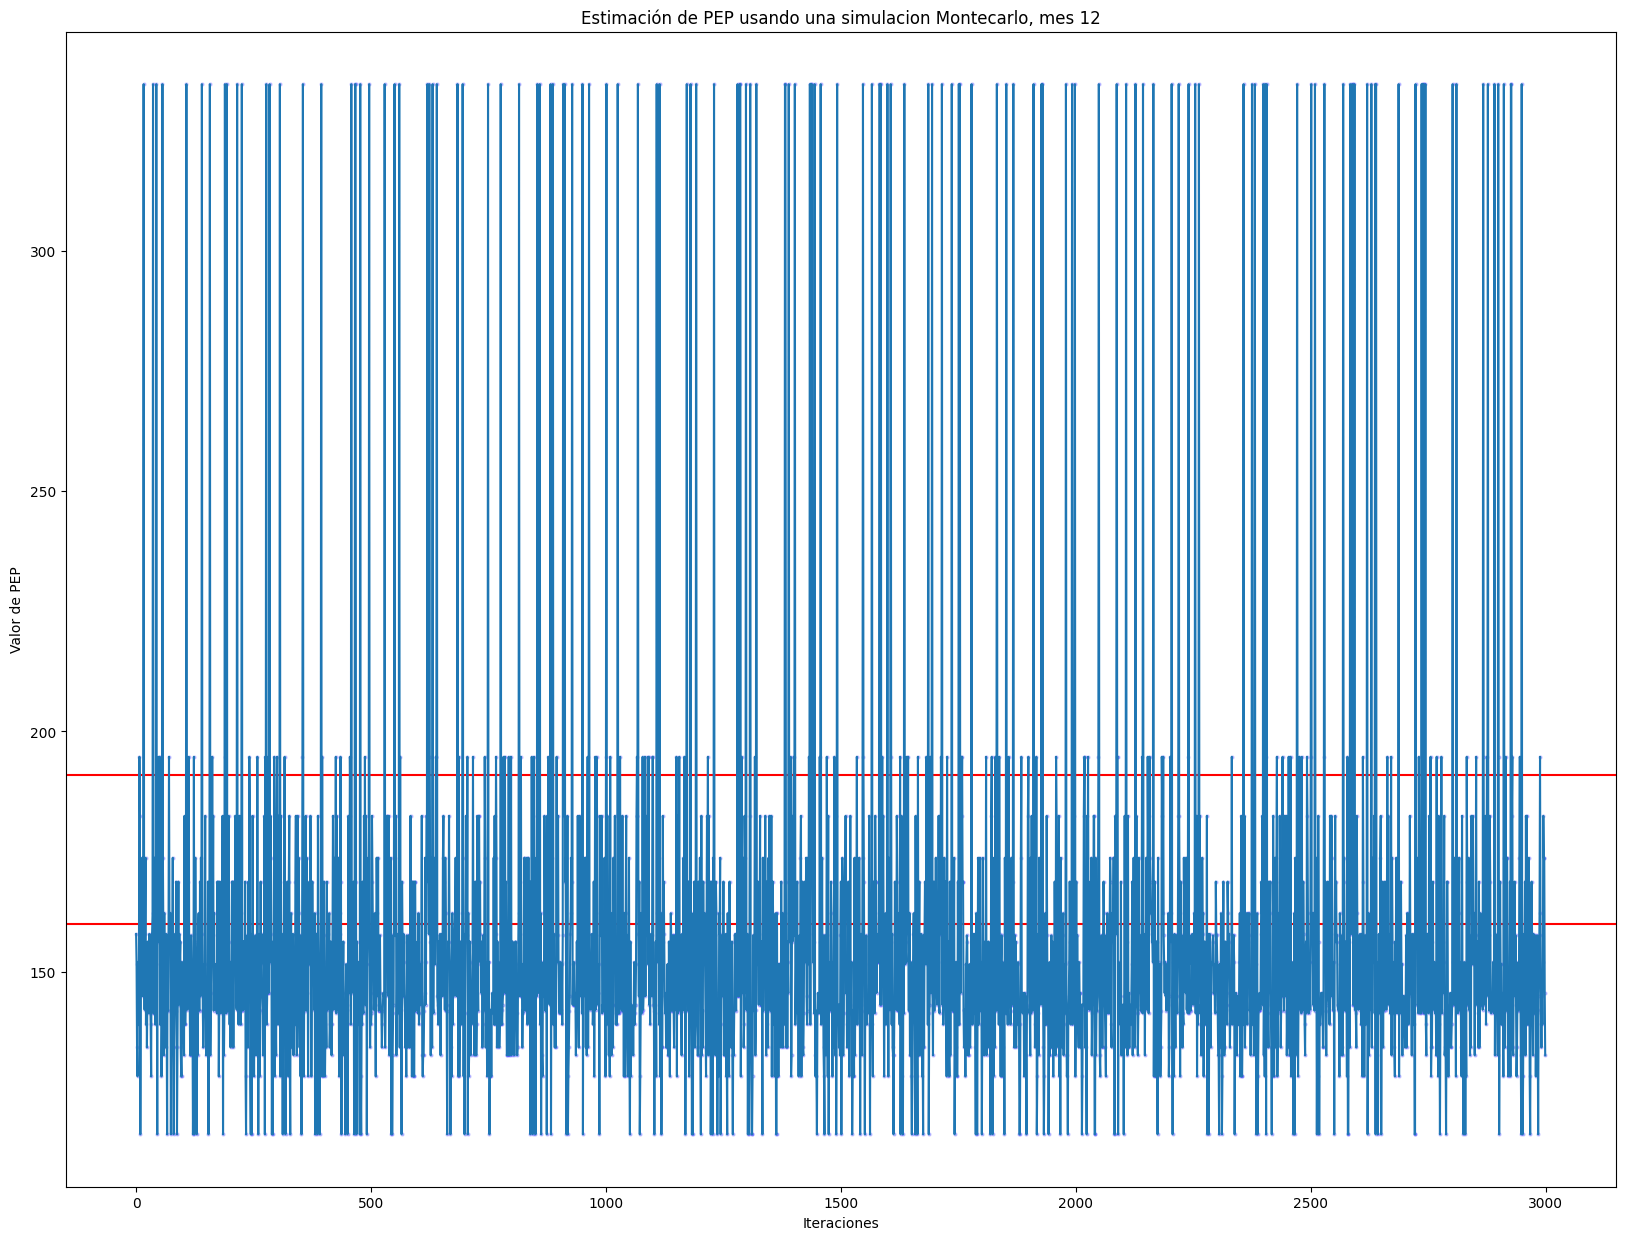

Porcentaje de exito: 17.933333333333334
La simulacion tomo: 6.148986339569092 s


In [7]:
monteCarlo3Time1 = time.time()
pep3 = monte_carlo(3000, 12)
monteCarlo3Time2 = time.time() - monteCarlo3Time1
print('La simulacion tomo:', monteCarlo3Time2, 's')

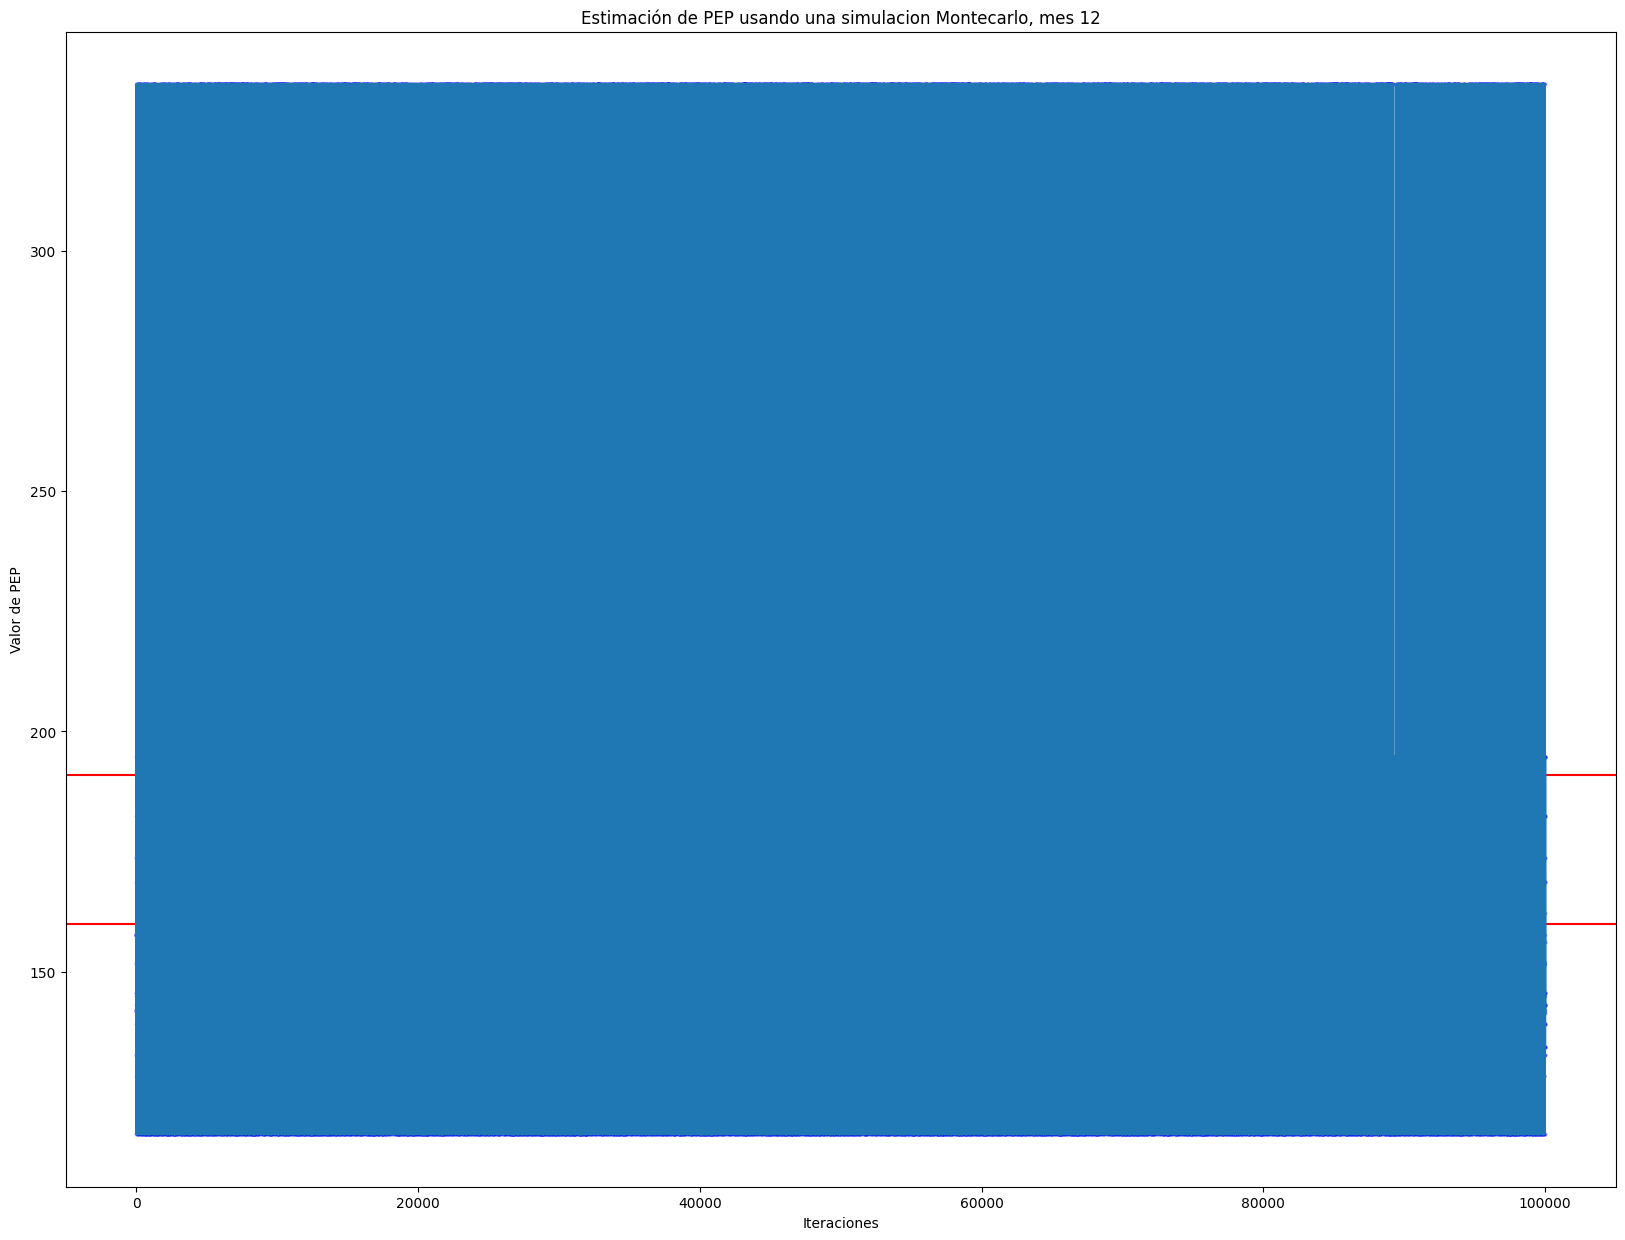

Porcentaje de exito: 18.096
La simulacion tomo: 125.61199951171875 s


In [8]:
monteCarlo4Time1 = time.time()
pep4 = monte_carlo(100000, 12)
monteCarlo4Time2 = time.time() - monteCarlo4Time1
print('La simulacion tomo:', monteCarlo4Time2, 's')

In [9]:
dfResultsMontecarlo = pd.DataFrame(data={
    'Metodo': ['1000 iteraciones, Abril', '2000 iteraciones, Junio', '3000 iteraciones, Diciembre', '100000 iteraciones, Diciembre'],
    'Probabilidad de Exito': [pep1, pep2, pep3, pep4],
    'Tiempo de ejecucion': [monteCarloTime2, monteCarlo2Time2, monteCarlo3Time2, monteCarlo4Time2]
})
dfResultsMontecarlo

,Metodo,Probabilidad de Exito,Tiempo de ejecucion
0,"1000 iteraciones, Abril",22.400000,2.336800
1,"2000 iteraciones, Junio",20.100000,4.094727
2,"3000 iteraciones, Diciembre",17.933333,6.148986
3,"100000 iteraciones, Diciembre",18.096000,125.612000


## Tarea 2: La Ruleta

Podemos tambien usar una simulacion monte carlo para esto.

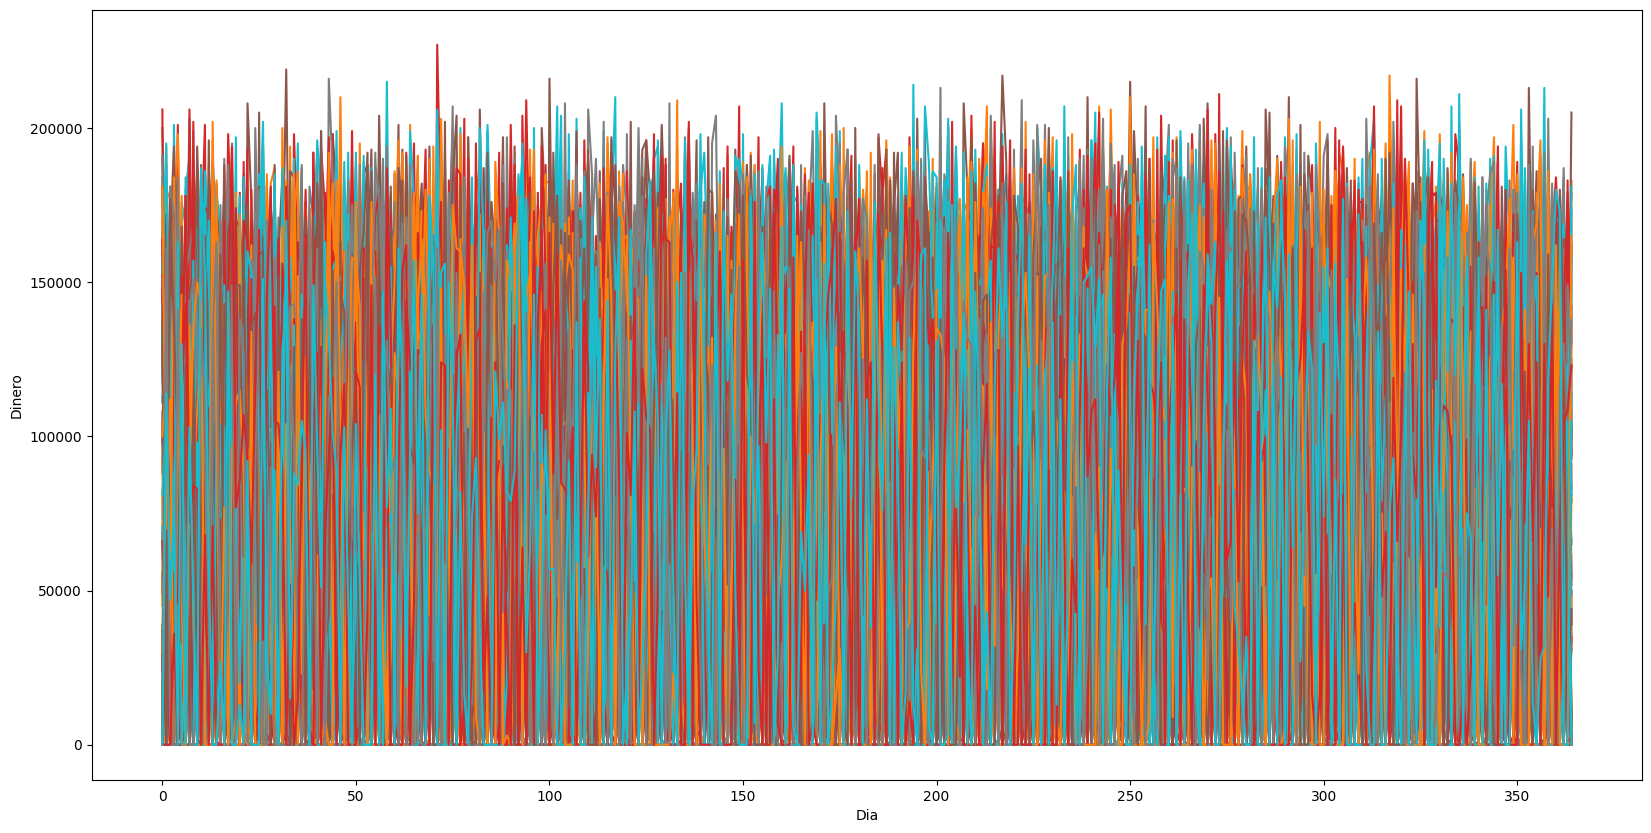

In [10]:
def monteCarloGambling(runs):
    plt.figure(figsize=(20, 10))
    totalLoss = 0
    maxTotal = []
    for i in range(runs):
        dayResults = []
        for j in range(365):
            cash = 200000
            attempts = 0
            loss = 0

            while (attempts <= 100) or (cash <= 0):
                attempts += 1
                res = random.randint(0, 36)

                if (res % 2) != 0:
                    cash += 1000
                    loss = 0
                else:
                    loss += 1
                    cash -= (1000 * (2 ** (loss - 1)))
                    totalLoss -= (1000 * (2 ** (loss - 1)))
                    if cash < 0:
                        cash = 0
                        break


            plt.plot(j, cash)
            dayResults.append(cash)
        maxperYear = max(dayResults)
        maxTotal.append(maxperYear)
        
        plt.plot(dayResults)

    
    plt.xlabel('Dia')
    plt.ylabel('Dinero')
    plt.show()

    return max(maxTotal), totalLoss

monteCarloGambling1Time1 = time.time()
results1, loss1 = monteCarloGambling(100)
monteCarloGambling1Time2 = time.time() - monteCarloGambling1Time1 


Podemos tambien probar otro caso... esta vez, que pasa si el hombre apuesta solo en 17?

Y al apostar, si gana y se multiplica por 35 lo que aposto, lo apuesta de nuevo?

Y Si el hombre pierde, pierde su apuesta e intenta de nuevo con la misma cantidad de dinero, no intenta multiplicar su apuesta por 2.

In [11]:
def monteCarloGambling2(runs):
    plt.figure(figsize=(20, 10))
    maxTotal = []
    totalLoss = 0
    for i in range(runs):
        dayResults = []
        for j in range(365):
            cash = 200000
            attempts = 0
            loss = 0
            bet = 1000
            while (attempts <= 100) or (cash <= 0):
                attempts += 1
                res = random.randint(0, 36)

                if res == 17:
                    cash += bet * 35
                    bet = bet * 35
                    loss = 0
                else:
                    loss += 1
                    cash -= bet
                    totalLoss += bet
                    if cash < 0:
                        cash = 0
                        break


            plt.plot(j, cash)
            dayResults.append(cash)
        maxperYear = max(dayResults)
        maxTotal.append(maxperYear)
        plt.plot(dayResults)
    
    
    
    plt.xlabel('Dia')
    plt.ylabel('Dinero')
    plt.show()
    maxTotalOverall = max(maxTotal)

    return maxTotalOverall, totalLoss

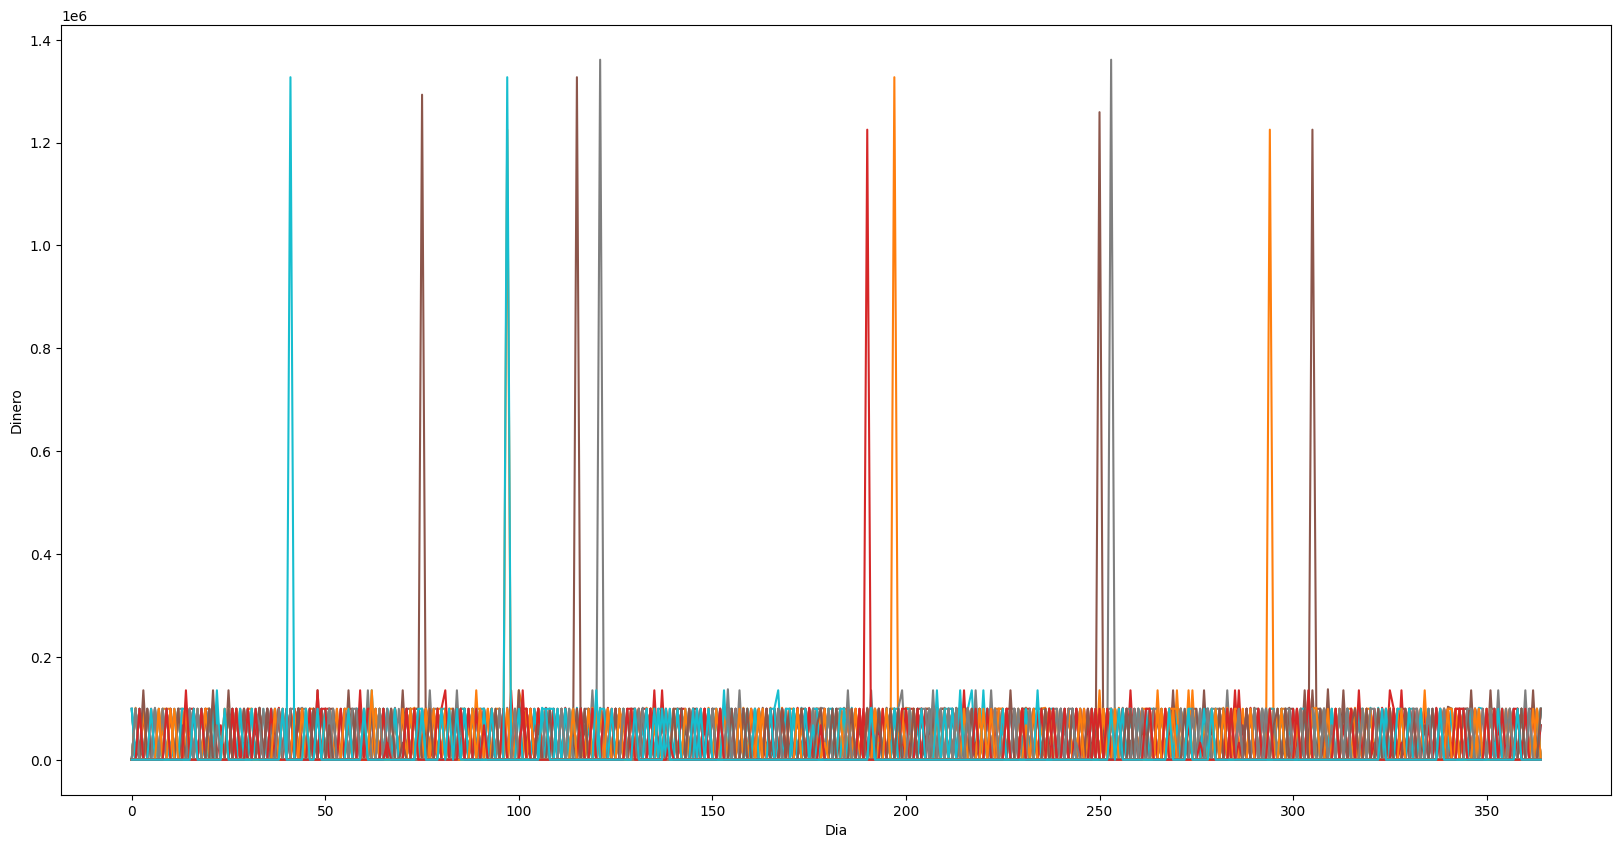

El maximo de dinero obtenido fue: 1361000


In [12]:
monteCarloGambling2Time1 = time.time()
results2, loss2 = monteCarloGambling2(100)
monteCarloGambling2Time2 = time.time() - monteCarloGambling2Time1

print(f'El maximo de dinero obtenido fue: {results2}')

In [13]:
print(results2)

1361000


Podemos hacer que el hombre se rinda y se retire al ganar 10 veces:

In [17]:
def monteCarloGambling3(runs):
    plt.figure(figsize=(20, 10))
    winAverage = []
    maxTotal = []
    retire = False
    retirementYear = 0
    totalLoss = 0
    for i in range(runs):
        winNumber = []
        if retire == True:
            retirementYear = i
            break
        dayResults = []
        for j in range(365):
            cash = 200000
            attempts = 0
            wins = 0 
            loss = 0
            bet = 1000
            while (attempts <= 100) or (cash <= 0):
                if attempts == 100:
                    cash += bet 
                if wins >= 8:
                    print('El hombre esta cerca de retirarse...')
                if wins >= 10:
                    retire = True

                attempts += 1
                res = random.randint(0, 36)

                if res == 17:
                    wins += 1
                    cash += bet * 35
                    bet = bet * 35
                    loss = 0
                else:
                    loss += 1
                    totalLoss += bet
                    cash -= bet
                    
                    if cash < 0:
                        cash = 0
                        break
            winNumber.append(wins)
            plt.plot(j, cash)
            dayResults.append(cash)
        maxperYear = max(dayResults)
        maxTotal.append(maxperYear)
        plt.plot(dayResults)
        winAverage.append(np.mean(winNumber))

    totalWinAverage = np.mean(winAverage)

    plt.xlabel('Dia')
    plt.ylabel('Dinero')
    plt.show()
    maxTotalOverall = max(maxTotal)
    if retire == True:
        print(f'El hombre se retiro, en el año {retirementYear}')
    maxWinsOverall = max(winNumber)
    print(f'El hombre gano {maxWinsOverall} veces como maximo, y gano {maxTotalOverall}, y el numero promedio de apuestas ganadas POR DÍA fue {totalWinAverage}')

    return maxTotalOverall, totalLoss

#### Veamos si el hombre puede retirarse.

Corramos una simulacion con... 500 iteraciones

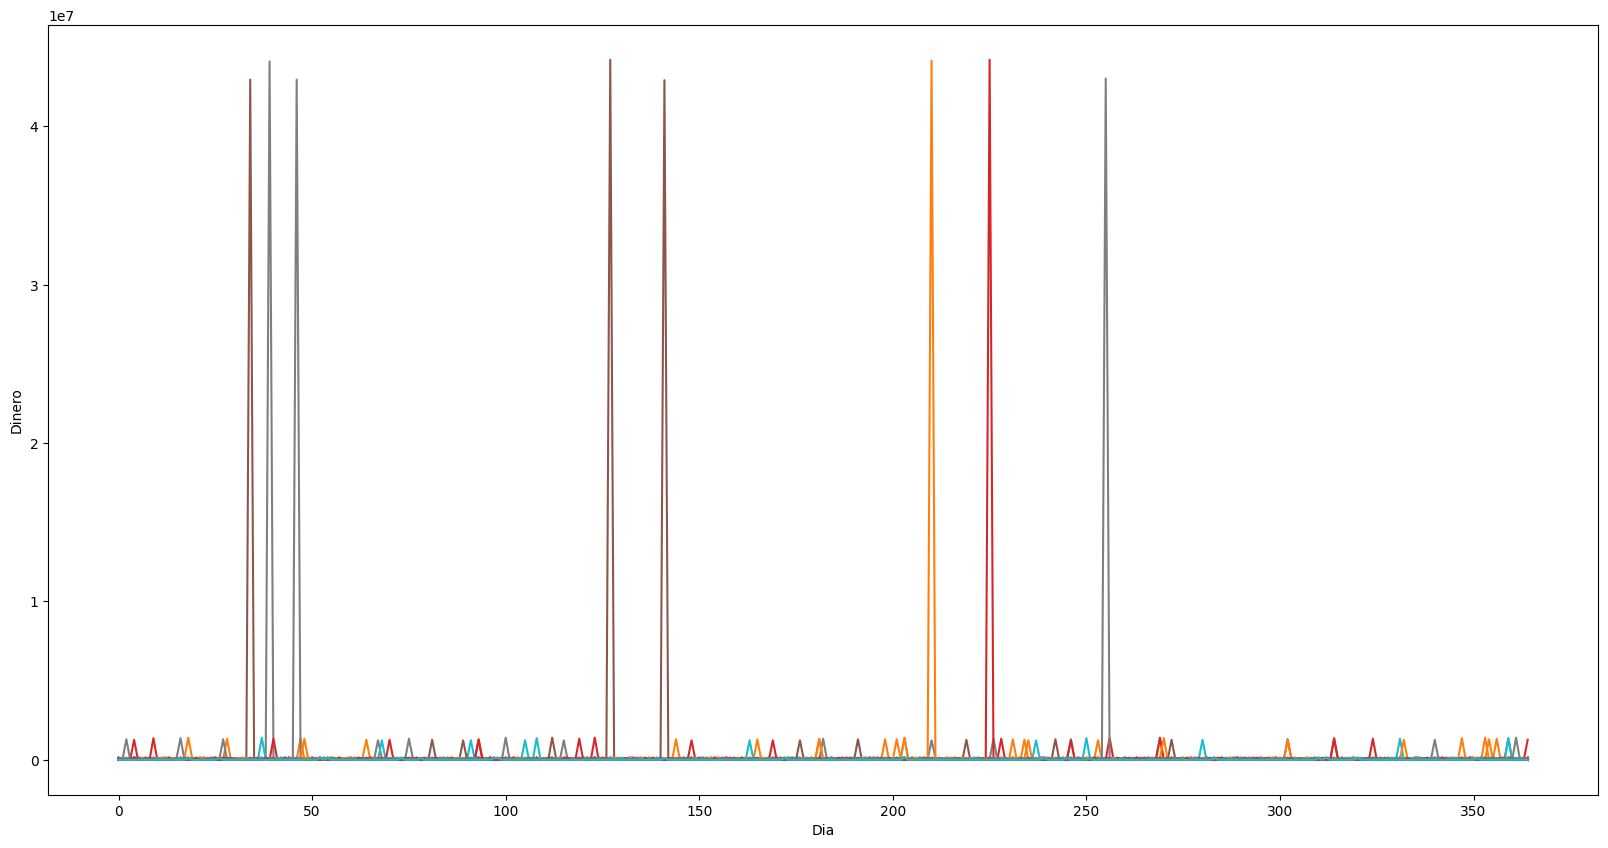

El hombre gano 3 veces como maximo, y gano 44204000, y el numero promedio de apuestas ganadas POR DÍA fue 1.0950356164383561
La simulacion tomo 177.5615816116333 segundos.


In [18]:
monteCarloGambling3Time1 = time.time()
results3, loss3 = monteCarloGambling3(500)
monteCarloGambling3Time2 = time.time() - monteCarloGambling3Time1 
print(f'La simulacion tomo {monteCarloGambling3Time2} segundos.')

Dataframe resultados

In [20]:
pd.set_option('display.max_colwidth', None)
resultDf = pd.DataFrame(data={
    'Metodo': ['Montecarlo Apuesta 1', 'Montecarlo Apuesta 2', 'Montecarlo Apuesta 3'],
    'Tiempo de ejecucion': [monteCarloGambling1Time2, monteCarloGambling2Time2, monteCarloGambling3Time2],
    'Ganancia maxima': [results1, results2, results3],
    'Perdida total': [loss1, loss2, loss3],
    'Descripcion Metodo': ['1000 en impar, duplicar apuesta si se pierde', '1000 en 17, apuestar lo ganado, apuesta lo que tiene si pierde', '1000 en 17, apuesta lo ganado, apuesta lo que tiene si pierde. Se retira si gana 10 veces']
})
display(resultDf)

,Metodo,Tiempo de ejecucion,Ganancia maxima,Perdida total,Descripcion Metodo
0,Montecarlo Apuesta 1,47.904431,227000,-6713207000,"1000 en impar, duplicar apuesta si se pierde"
1,Montecarlo Apuesta 2,48.257184,1361000,196196291000,"1000 en 17, apuestar lo ganado, apuesta lo que tiene si pierde"
2,Montecarlo Apuesta 3,177.561582,44204000,982174557000,"1000 en 17, apuesta lo ganado, apuesta lo que tiene si pierde. Se retira si gana 10 veces"
